### 1. Configuration

In [106]:
import pandas as pd
import numpy as np

In [185]:
df_customer = pd.read_csv("olist_customers_dataset.csv")
df_geolocation = pd.read_csv("olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("olist_order_items_dataset.csv")
df_order_payments = pd.read_csv("olist_order_payments_dataset.csv")
df_order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("olist_orders_dataset.csv")
df_products = pd.read_csv("olist_products_dataset.csv")
df_sellers  = pd.read_csv("olist_sellers_dataset.csv")
df_product_translation = pd.read_csv("product_category_name_translation.csv")

list_df = { 
    "df_customer": df_customer,
    "df_geolocation": df_geolocation,
    "df_order_items": df_order_items,
    "df_order_payments": df_order_payments,
    "df_order_reviews": df_order_reviews,
    "df_orders": df_orders,
    "df_products": df_products,
    "df_sellers": df_sellers,
    "df_product_translation": df_product_translation
    } 


### 2. Exploring Datasets

In [108]:
df_customer.head(2)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [109]:
df_geolocation.head(2)

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP


In [110]:
df_order_items.head(2)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


In [111]:
df_order_payments.head(2)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39


In [112]:
df_order_reviews.head(2)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13


In [113]:
df_orders.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [114]:
df_products.head(2)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0


In [115]:
df_sellers.head(2)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


In [116]:
df_product_translation.head(2)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


### 3. Informations of datasets

#### 3.1. Basic data

In [186]:
# Lenght of datasets

for key, value in list_df.items():
    print(f"{key}: {len(value)} items." )


df_customer: 99441 items.
df_geolocation: 1000163 items.
df_order_items: 112650 items.
df_order_payments: 103886 items.
df_order_reviews: 99224 items.
df_orders: 99441 items.
df_products: 32951 items.
df_sellers: 3095 items.
df_product_translation: 71 items.


#### 3.2. NULL Data Treatment

In [187]:
for df_name, df in list_df.items():
    print(f"{df_name}")
    print(df.isnull().sum())
    print()

# df_customer, df_geolocation, df_order_items, df_order_payments, df_sellers -> No NULL
# df_order_reviews -> NULL just in text columns, replace with "no comment"
# df_orders -> NULL bring information of status of order -> no approved, no delivered to customer ou no delivered to logistic partner -> it will not be alterations
# df_products -> columns of name and category means product with no identification | columns of measures -> replace with mode or mean (just 2)
# df_product_translation -> just support df

df_customer
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

df_geolocation
geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

df_order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

df_order_payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

df_order_reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

df

##### 3.2.1. df_order_reviews


In [188]:
# -> replace with "no comment"
fill = ["review_comment_title", "review_comment_message"]

df_order_reviews[fill] = df_order_reviews[fill].fillna("no_comments")
df_order_reviews.isnull().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

##### 3.2.2. df_products

In [189]:
# -> columns that means that we no have info, we need to put this
# -> columns that with the measure of two products, 1 we will input the mode of category and 1 we wil remove

no_info = ["product_category_name", "product_name_lenght", "product_description_lenght", "product_photos_qty"]
mean_info = ["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]

In [194]:
df_products[no_info] = df_products[no_info].fillna("no_information")

In [198]:
df_products_mean = df_products.groupby(by="product_category_name")[mean_info].mean()
list = df_products["product_category_name"].dropna().unique()

for col in mean_info:
    for cat in list:
        X = df_products_mean.loc[cat][col]
        mask = df_products["product_category_name"] == cat

        df_products.loc[mask, col] = (df_products.loc[mask, col].fillna(X))

df_products = df_products.dropna()
df_products.isnull().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

#### 3.3. Checking duplicates values

- **df_customer:** keep this way, only when count customer we had to use unique_customer_id.
- **df_geolocation:** it has geolocation per zip code, so we need to extracted the mean() of it per city -> Transforming df.
- **df_order_items:** no duplicated values, it is a list of each product inside a order. We need to summarize it -> Transforming df.
- **df_order_payments:** we have 100k lines but only 99k unique order_id. Some payments were splited, but the value is tha same in df_group_orders. Drop sequentical and pick the others.
- **df_order_reviews:** we have some incosistents -> more than one review per order and more than one order per review. Need to 1 x 1.
- **df_orders:** it's ok.
- **df_products:** it's ok.
- **df_sellers:** it's ok.
- **df_product_translation:** it's ok. 

In [122]:
for name, df in list_df.items():
    if name == "df_customer":
        print(name)
        print(df[["customer_id", "customer_unique_id"]].nunique())
        print(len(df))
        print()
    elif name == "df_geolocation":
        print(name)
        print(df[["geolocation_city"]].nunique())
        print(len(df))
        print()
    elif name == "df_order_items":
        print(name)
        print(df[["order_id", "product_id"]].nunique())
        print(len(df))
        print()
    elif name == "df_order_payments":
        print(name)
        print(df[["order_id"]].nunique())
        print(len(df))
        print()
    elif name == "df_order_reviews":
        print(name)
        print(df[["review_id", "order_id"]].nunique())
        print(len(df))
        print()
    elif name == "df_orders":
        print(name)
        print(df[["order_id"]].nunique())
        print(len(df))
        print()
    elif name == "df_products":
        print(name)
        print(df[["product_id"]].nunique())
        print(len(df))
        print()
    elif name == "df_sellers":
        print(name)
        print(df[["seller_id"]].nunique())
        print(len(df))
        print()
    elif name == "df_product_translation":
        print(name)
        print(df[["product_category_name", "product_category_name_english"]].nunique())
        print(len(df))
        print()

df_customer
customer_id           99441
customer_unique_id    96096
dtype: int64
99441

df_geolocation
geolocation_city    8011
dtype: int64
1000163

df_order_items
order_id      98666
product_id    32951
dtype: int64
112650

df_order_payments
order_id    99440
dtype: int64
103886

df_order_reviews
review_id    98410
order_id     98673
dtype: int64
99224

df_orders
order_id    99441
dtype: int64
99441

df_products
product_id    32951
dtype: int64
32951

df_sellers
seller_id    3095
dtype: int64
3095

df_product_translation
product_category_name            71
product_category_name_english    71
dtype: int64
71



##### 3.3.1. df_order_payments

In [123]:
print(df_order_payments["order_id"].nunique())
print(len(df_order_payments))

99440
103886


In [124]:
df_order_payments = df_order_payments.drop(columns=["payment_sequential"])
df_order_payments = df_order_payments.groupby(by="order_id").agg({"payment_installments":"max", "payment_value":"sum", "payment_type":"max"}).reset_index()

print(df_order_payments["order_id"].nunique())
print(len(df_order_payments))

99440
99440


##### 3.3.2. df_order_reviews

In [125]:
# Checking if we have 1 order_id x 1 review_id
print(df_order_reviews[["review_id", "order_id"]].nunique())
print(len(df_order_reviews))

review_id    98410
order_id     98673
dtype: int64
99224


In [126]:
df_order_reviews = (
    df_order_reviews
        .sort_values(by=["review_score"])
        .drop_duplicates(subset=["review_id"], keep="first", ignore_index=True)
    )

df_order_reviews = (
    df_order_reviews
        .sort_values(by=["review_score"])
        .drop_duplicates(subset=["order_id"], keep="first", ignore_index=True)
    )

print(df_order_reviews[["review_id", "order_id"]].nunique()) # 1 order_id x 1 review_id
print(len(df_order_reviews))

review_id    98120
order_id     98120
dtype: int64
98120


#### 3.4. Tranforming the datasets

##### 3.4.1. df_orders_items

In [127]:
# df_order_items -> need to agroup the information because we have more than 1 line per order

columns = ["order_item_id", "price", "freight_value"]

df_group_orders = df_order_items.groupby(by="order_id", as_index=False)[columns].agg(
                                                    total_items = ("order_item_id", "count"),
                                                    order_total_price = ("price", "sum"),
                                                    freight_total_price = ("freight_value", "sum")
                                                    )

df_group_orders.head(2)

,order_id,total_items,order_total_price,freight_total_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,239.9,19.93


##### 3.4.2. df_geolocation

In [128]:
import unicodedata

def limpar_texto(texto):
    if isinstance(texto, str):
        texto = unicodedata.normalize('NFKD', texto)
        texto = ''.join(c for c in texto if not unicodedata.combining(c))
        return texto.lower()
    return texto

In [129]:
# google resarch, in Brasil the values of latitute and longitude must be between:
# latitute: -33.751° and +5.272°
# longitude: -73.991° and -33.751°

df_geolocation = df_geolocation[
    (df_geolocation["geolocation_lat"] > -34) & 
    (df_geolocation["geolocation_lat"] < 6)   &
    (df_geolocation["geolocation_lng"] > -74) &
    (df_geolocation["geolocation_lng"] < -34)
    ]

In [167]:
df_geolocation = df_geolocation.copy()

df_geolocation["geolocation_city"] = df_geolocation["geolocation_city"].apply(limpar_texto)
df_geolocation["geolocation_state"] = df_geolocation["geolocation_state"].apply(limpar_texto)

df_city = df_geolocation.groupby(["geolocation_state", "geolocation_city"]).agg(
    lat_mean=("geolocation_lat", "mean"),
    lng_mean=("geolocation_lng", "mean")
).reset_index()

df_city.head()

,geolocation_state,geolocation_city,lat_mean,lng_mean
0,ac,acrelandia,-10.059374,-67.037486
1,ac,assis brasil,-10.935106,-69.557831
2,ac,brasileia,-11.005941,-68.749175
3,ac,bujari,-9.798651,-68.004247
4,ac,campinas,-22.861615,-47.064303


In [132]:
df_customer["customer_city"] = df_customer["customer_city"].apply(limpar_texto)
df_customer["customer_state"] = df_customer["customer_state"].apply(limpar_texto)

df_customer_geo = df_customer[["customer_id", "customer_city", "customer_state"]].merge(
    df_city[["geolocation_city", "geolocation_state", "lat_mean", "lng_mean"]],
    left_on=["customer_city", "customer_state"],
    right_on=["geolocation_city", "geolocation_state"],
    how="left"
).drop(columns=["geolocation_city", "geolocation_state"]).rename(columns={"lat_mean": "customer_lat", "lng_mean": "customer_lng"})

df_customer_geo.head(2)

,customer_id,customer_city,customer_state,customer_lat,customer_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,franca,sp,-20.534057,-47.398437
1,18955e83d337fd6b2def6b18a428ac77,sao bernardo do campo,sp,-23.707526,-46.563858


In [133]:
df_sellers["seller_city"] = df_sellers["seller_city"].apply(limpar_texto)
df_sellers["seller_state"] = df_sellers["seller_state"].apply(limpar_texto)

df_seller_geo = df_sellers[["seller_id", "seller_city", "seller_state"]].merge(
    df_city[["geolocation_city", "geolocation_state", "lat_mean", "lng_mean"]],
    left_on=["seller_city", "seller_state"],
    right_on=["geolocation_city", "geolocation_state"],
    how="left"
).drop(columns=["geolocation_city", "seller_state"]).rename(columns={"lat_mean": "seller_lat", "lng_mean": "seller_lng"})

df_seller_geo.head(2)

,seller_id,seller_city,geolocation_state,seller_lat,seller_lng
0,3442f8959a84dea7ee197c632cb2df15,campinas,sp,-22.900868,-47.068537
1,d1b65fc7debc3361ea86b5f14c68d2e2,mogi guacu,sp,-22.356277,-46.940810


### 4. Data Analysis

In [134]:
columns = [
    "order_id", "order_status", "order_purchase_timestamp", "order_delivered_carrier_date", 
    "order_delivered_customer_date", "customer_unique_id", "customer_city", "customer_state",
    "total_items", "order_total_price", "freight_total_price"]

df_1 = (df_orders.merge(df_customer, how="left", on="customer_id")).merge(df_group_orders, how="left", on="order_id")
df_1 = df_1[columns]
df_1.head()

,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,customer_unique_id,customer_city,customer_state,total_items,order_total_price,freight_total_price
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,7c396fd4830fd04220f754e42b4e5bff,sao paulo,sp,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,af07308b275d755c9edb36a90c618231,barreiras,ba,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 13:50:00,2018-08-17 18:06:29,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,go,1.0,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,rn,1.0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-14 19:46:34,2018-02-16 18:17:02,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,sp,1.0,19.90,8.72


#### 4.1. Financial Metrics

In [135]:
import matplotlib.pyplot as plt

##### 4.1.1. Value Spent per State

In [136]:
df_states = df_1.groupby(by="customer_state").agg(
    total_itens   = ("total_items", "sum"),
    total_value   = ("order_total_price", "sum"),
    total_freight = ("freight_total_price", "sum")
)

df_states["total_spent_milion"] = (df_states["total_value"] + df_states["total_freight"])/1000000

df_states = df_states.reset_index().sort_values(by="total_spent_milion", ascending=True)

df_states.head(2)

,customer_state,total_itens,total_value,total_freight,total_spent_milion
21,rr,52.0,7829.43,2235.19,0.010065
3,ap,82.0,13474.30,2788.50,0.016263


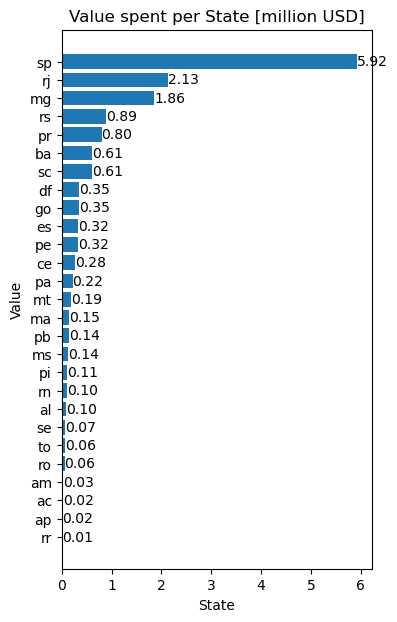

In [137]:
plt.figure(figsize=(4,7))

bars = plt.barh(df_states["customer_state"], df_states["total_spent_milion"])

plt.bar_label(bars, fmt="%.2f")

plt.xlabel("State")
plt.ylabel("Value")
plt.title("Value spent per State [million USD]")
plt.show()

##### 4.1.2. Purchase Quantity per Month

In [138]:
data_columns = [
    "order_purchase_timestamp", "order_delivered_carrier_date", "order_delivered_customer_date"
    ]

df_1[data_columns] = df_1[data_columns].astype(dtype='datetime64[ns]')

df_1.head()

,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,customer_unique_id,customer_city,customer_state,total_items,order_total_price,freight_total_price
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,7c396fd4830fd04220f754e42b4e5bff,sao paulo,sp,1.0,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,af07308b275d755c9edb36a90c618231,barreiras,ba,1.0,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-08 13:50:00,2018-08-17 18:06:29,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,go,1.0,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,rn,1.0,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39,2018-02-14 19:46:34,2018-02-16 18:17:02,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,sp,1.0,19.90,8.72


In [139]:
df_1["purchase_month"] = df_1["order_purchase_timestamp"].dt.month

df_purchase = pd.DataFrame(df_1.groupby(by="purchase_month")["total_items"].sum()).reset_index()
df_purchase.head(2)

,purchase_month,total_items
0,1,9163.0
1,2,9623.0


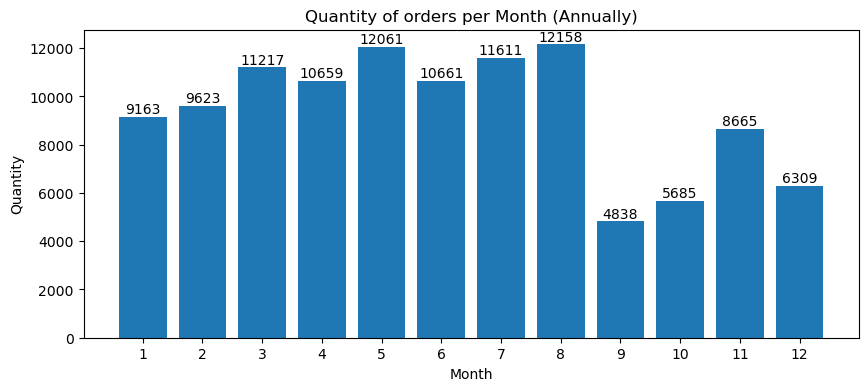

In [140]:
plt.figure(figsize=(10,4))

bars = plt.bar(
    df_purchase["purchase_month"], 
    df_purchase["total_items"]
    )

plt.bar_label(bars, fmt="%d")
plt.title("Quantity of orders per Month (Annually)")
plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.show()

#### 4.2. Orders Metrics

##### 4.2.1. Status of the orders

In [141]:
pd.concat([df_1["order_status"].value_counts(),round(df_1["order_status"].value_counts(normalize=True)*100,2)],axis=1).reset_index()

,order_status,count,proportion
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


##### 4.2.2. Distance between Customer and Seller

In [142]:
df_2 = (
    df_orders[["order_id", "customer_id"]]
        .merge(df_order_items[["order_id", "seller_id"]], on="order_id", how="left")
        .merge(df_customer_geo[["customer_id", "customer_city", "customer_lat", "customer_lng"]], on="customer_id", how="left") 
        .merge(df_seller_geo[["seller_id", "seller_city", "seller_lat", "seller_lng"]], on="seller_id", how="left")
    ).drop(columns=["customer_id", "seller_id"])

df_2["customer_lat"] = np.deg2rad(df_2["customer_lat"])
df_2["customer_lng"] = np.deg2rad(df_2["customer_lng"])
df_2["seller_lat"]   = np.deg2rad(df_2["seller_lat"])
df_2["seller_lng"]   = np.deg2rad(df_2["seller_lng"])

df_2["lat_dif"] = df_2["customer_lat"] - df_2["seller_lat"]
df_2["lng_dif"] = df_2["customer_lng"] - df_2["seller_lng"]

df_2 = df_2.dropna()

df_2.head(2)

,order_id,customer_city,customer_lat,customer_lng,seller_city,seller_lat,seller_lng,lat_dif,lng_dif
0,e481f51cbdc54678b7cc49136f2d6af7,sao paulo,-0.411396,-0.813915,maua,-0.413120,-0.810686,0.001724,-0.003229
2,47770eb9100c2d0c44946d9cf07ec65d,vianopolis,-0.292268,-0.846745,guariba,-0.372863,-0.841765,0.080595,-0.004979


In [143]:
# Distance of coordinates in km
# d = 2 x R x arcsin[sqrt(sin²(lat_dif / 2) + cos(lat1)*cos(lat2)*sin²(lng_dif / 2))]

# R = r of Earth [km] = 6.371
# lat1 and lat2 = latitude of point1 and point2 [radians]
# lat_dif = diference between lat1 and lat2 [radians]
# lng_dif = diference between lng1 and lng2 [radians]

R = 6371
df_2["distance_km"] = 2 * R * np.arcsin(np.sqrt((np.sin(df_2["lat_dif"]/2))**2 + np.cos(df_2["customer_lat"])*np.cos(df_2["seller_lat"] )*(np.sin(df_2["lng_dif"]/2))**2 ))

<Axes: ylabel='Frequency'>

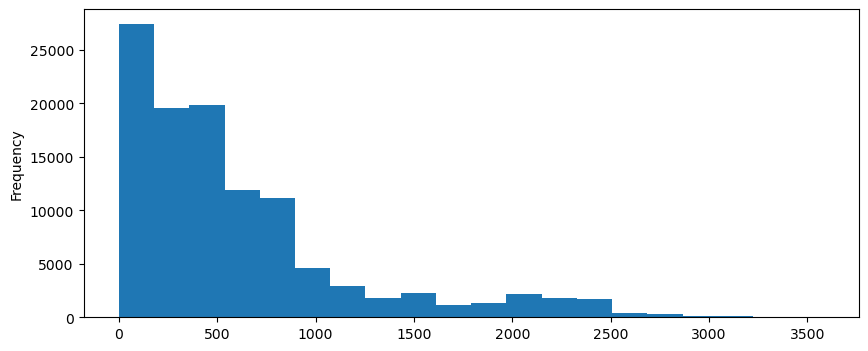

In [144]:
df_2["distance_km"].plot(kind="hist", bins=20, figsize=(10,4))

In [145]:
df_2.sort_values(by="distance_km", ascending=False).head()

,order_id,customer_city,customer_lat,customer_lng,seller_city,seller_lat,seller_lng,lat_dif,lng_dif,distance_km
65239,e9874f4e48ede77b6b9d785ac3755445,boa vista,0.049309,-1.059382,bombinhas,-0.473972,-0.846541,0.523281,-0.212841,3581.220782
49755,9b790ca446b8e28ce5e4382959f6b7df,boa vista,0.049309,-1.059382,fazenda rio grande,-0.447780,-0.860624,0.497089,-0.198758,3396.210394
43503,2889d7816934298a0f5a4a30ef3ffbc7,boa vista,0.049309,-1.059382,sao jose dos pinhais,-0.445602,-0.858271,0.494911,-0.201112,3388.719254
31,ecab90c9933c58908d3d6add7c6f5ae3,boa vista,0.049309,-1.059382,curitiba,-0.444240,-0.860011,0.493549,-0.199371,3376.808943
16749,be5cae366c82f548c9a28b353ab44dd0,boa vista,0.049309,-1.059382,curitiba,-0.444240,-0.860011,0.493549,-0.199371,3376.808943


##### 4.2.3. Categories of products

In [147]:
df_3 = (
    df_order_items[["product_id", "price", "freight_value"]]
        .merge(df_products[["product_id", "product_category_name"]], on="product_id", how="left")
        .merge(df_product_translation, on="product_category_name", how="left")).drop(columns=["product_category_name"]
        )
df_3["total_price"] = df_3["price"] + df_3["freight_value"]
df_3.head(2)

,product_id,price,freight_value,product_category_name_english,total_price
0,4244733e06e7ecb4970a6e2683c13e61,58.9,13.29,cool_stuff,72.19
1,e5f2d52b802189ee658865ca93d83a8f,239.9,19.93,pet_shop,259.83


In [148]:
df_3 = pd.DataFrame(df_3.groupby(by="product_category_name_english")["total_price"].mean()).reset_index().rename(columns={"product_category_name_english":"product_category"}).sort_values(by="total_price")
df_3.head(2)

,product_category,total_price
46,home_comfort_2,39.019333
35,flowers,48.451818


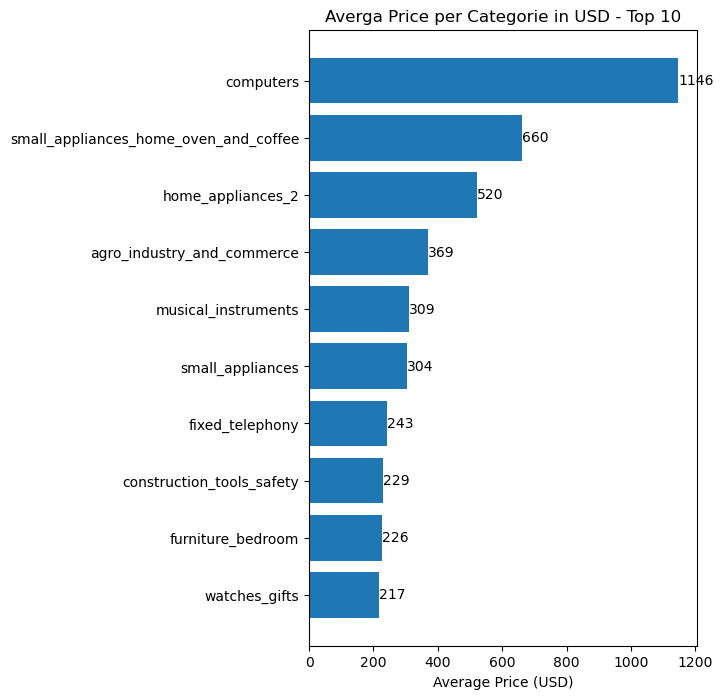

In [149]:
plt.figure(figsize=(5,8))

bars = plt.barh(
    df_3["product_category"].tail(10),
    df_3["total_price"].tail(10)
)

plt.bar_label(bars, fmt="%d")
plt.xlabel("Average Price (USD)")
plt.title("Averga Price per Categorie in USD - Top 10")
plt.show()

##### 4.2.4. Reviews

In [150]:
df_4 = pd.concat([
    df_order_reviews["review_score"].value_counts(),
    round(df_order_reviews["review_score"].value_counts(normalize=True)*100,2)
    ],axis=1).reset_index().sort_values(by="review_score").reset_index(drop=True)

df_4

,review_score,count,proportion
0,1,11261,11.48
1,2,3107,3.17
2,3,8073,8.23
3,4,18959,19.32
4,5,56720,57.81


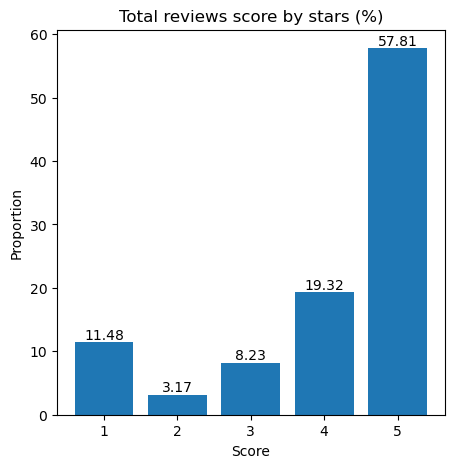

In [151]:
plt.figure(figsize=(5,5))

bars = plt.bar(
    df_4["review_score"],
    df_4["proportion"]
    )

plt.bar_label(bars, fmt="%.2f")
plt.xlabel("Score")
plt.ylabel("Proportion")
plt.title("Total reviews score by stars (%)")

plt.show()

#### 4.3. Dataset to ML

In [152]:
from datetime import datetime

In [153]:
# Variables:
#   1 - time_delivered ok
#   2 - distance_km ok
#   3 - total itens
#   4 - order_total_price
#   5 - freight_total_price
#   6 - payment_type
#   7-  payment_installments

# Target Variable: review_score -> the customer will be satisfied or not?

In [154]:
df_order_reviews["order_id"].nunique()

98120

In [155]:
df_5 = df_1[["order_id", "order_purchase_timestamp", "order_delivered_customer_date"]][df_1["order_status"] == "delivered"]
df_5["delivered_time"] = df_5["order_delivered_customer_date"] - df_5["order_purchase_timestamp"]
df_5 = df_5.dropna()

In [156]:
df_5["delivered_time_second"] = df_5["delivered_time"].apply(lambda x: x.total_seconds())
df_5 = df_5.drop(columns=["order_purchase_timestamp", "order_delivered_customer_date", "delivered_time"])
df_5.head()

,order_id,delivered_time_second
0,e481f51cbdc54678b7cc49136f2d6af7,728920.0
1,53cdb2fc8bc7dce0b6741e2150273451,1190768.0
2,47770eb9100c2d0c44946d9cf07ec65d,811660.0
3,949d5b44dbf5de918fe9c16f97b45f8a,1141236.0
4,ad21c59c0840e6cb83a9ceb5573f8159,248303.0


In [157]:
df_ml = (
    df_5
        .merge(df_2[["order_id", "distance_km"]], on="order_id", how="left")
        .merge(df_group_orders, on="order_id", how="left")
        .merge(df_order_payments[["order_id", "payment_type", "payment_installments"]], on="order_id", how="left")
        .merge(df_order_reviews[["order_id", "review_score"]], on="order_id", how="left")
)

df_ml.head()

,order_id,delivered_time_second,distance_km,total_items,order_total_price,freight_total_price,payment_type,payment_installments,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,728920.0,21.812691,1,29.99,8.72,voucher,1.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,1190768.0,NaN,1,118.70,22.76,boleto,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,811660.0,514.347059,1,159.90,19.22,credit_card,3.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,1141236.0,1829.329388,1,45.00,27.20,credit_card,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,248303.0,36.414651,1,19.90,8.72,credit_card,1.0,5.0


In [158]:
df_ml.isnull().sum()

order_id                    0
delivered_time_second       0
distance_km              1774
total_items                 0
order_total_price           0
freight_total_price         0
payment_type                3
payment_installments        3
review_score             1401
dtype: int64

In [159]:
df_ml = df_ml.dropna()

### 5. Machine Learning

In [160]:
from sklearn import linear_model
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

#### 5.1. Linear Regression

In [161]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df_ml[["payment_type"]])
df_encoded = pd.DataFrame(
    encoded, 
    columns=encoder.get_feature_names_out(["payment_type"]),
    index=df_ml.index)

df_ml = pd.concat([df_ml, df_encoded], axis=1).drop(columns=["payment_type"])

In [162]:
df_ml.head(2)

,order_id,delivered_time_second,distance_km,total_items,order_total_price,freight_total_price,payment_installments,review_score,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_voucher
0,e481f51cbdc54678b7cc49136f2d6af7,728920.0,21.812691,1,29.99,8.72,1.0,4.0,0.0,0.0,0.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,811660.0,514.347059,1,159.90,19.22,3.0,5.0,0.0,1.0,0.0,0.0


In [163]:
# dependent variable:
y = df_ml["review_score"]

# independent variables:
list = [
    "delivered_time_second", "distance_km", "total_items", "order_total_price", 
    "freight_total_price", "payment_installments", "payment_type_boleto", 
    "payment_type_credit_card", "payment_type_debit_card", "payment_type_voucher"
    ]

X = df_ml[list]

In [164]:
lm = linear_model.LinearRegression()

In [165]:
lm.fit(X=X, y=y)

LinearRegression()

In [166]:
lm.score(X, y)

0.13001880346810013